## 1. Setup

Run the cells from top to bottom using `.venv-1`. This cell locates the project, imports libraries, and loads the original and cleaned scraped CSV files. Prices are in LKR lakhs (1 lakh = 100,000 rupees).


In [ ]:
# Setup: Import libraries and locate project inputs.
from pathlib import Path
import sys
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# This works when the notebook is inside the notebooks folder
ROOT = Path.cwd().resolve()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if not (ROOT / "data").exists():
    raise FileNotFoundError(
        "Project folder was not found. Open this notebook from the AutoValue project."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

LEGACY_PATH = ROOT / "data" / "raw" / "car_price_dataset.csv"
SCRAPED_PATH = ROOT / "data_collection" / "cleaned_new_data.csv"
OUTPUT_PATH = ROOT / "data" / "cars.csv"
MODEL_PATH = ROOT / "models" / "selected_six_model.joblib"

REFERENCE_YEAR = 2026
RANDOM_STATE = 42

print("Project:", ROOT)
print("Python:", sys.executable)
# Load the two input datasets and remove exported index columns.
legacy_raw = pd.read_csv(LEGACY_PATH)
legacy_raw = legacy_raw.loc[:, ~legacy_raw.columns.str.startswith("Unnamed:")]
scraped_raw = pd.read_csv(SCRAPED_PATH)
print("Input shapes:", legacy_raw.shape, scraped_raw.shape)


Project: /Users/kathuskanthavarajah/Desktop/used_car_valuation_project
Python: /Users/kathuskanthavarajah/Desktop/used_car_valuation_project/.venv-1/bin/python
Input shapes: (9788, 16) (2252, 10)


In [91]:
# 1. Load the raw dataset
raw_df = pd.read_csv('../data/raw/car_price_dataset.csv')

# Define all 16 features
features = [
    'Brand', 'Model', 'YOM', 'Engine (cc)', 'Gear', 'Fuel Type', 
    'Millage(KM)', 'Town', 'Date', 'Leasing', 'Condition', 
    'AIR CONDITION', 'POWER STEERING', 'POWER MIRROR', 'POWER WINDOW', 'Price'
]

df_corr = raw_df[features].copy()

# 2. Encode binary/accessory columns
bool_cols = ['Leasing', 'AIR CONDITION', 'POWER STEERING', 'POWER MIRROR', 'POWER WINDOW']
for col in bool_cols:
    df_corr[col] = df_corr[col].astype(str).str.lower().map(
        {'yes': 1, 'no': 0, 'true': 1, 'false': 0, '1': 1, '0': 0}
    )
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce').fillna(0)

# 3. Ensure base numeric columns are floats
num_cols = ['YOM', 'Engine (cc)', 'Millage(KM)', 'Price']
for col in num_cols:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')

# 4. Label Encode categorical text
cat_cols = ['Brand', 'Model', 'Gear', 'Fuel Type', 'Town', 'Condition', 'Date']
le = LabelEncoder()
for col in cat_cols:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# 5. Calculate and print the correlation with Price as text
corr_matrix = df_corr.corr()
price_correlation = corr_matrix[['Price']].sort_values(by='Price', ascending=False)

print("--- CORRELATION WITH PRICE ---")
print(price_correlation.to_string())

--- CORRELATION WITH PRICE ---
                   Price
Price           1.000000
YOM             0.506669
Engine (cc)     0.193737
Date            0.026392
Condition      -0.007273
Model          -0.045214
Fuel Type      -0.048933
Town           -0.060996
Brand          -0.066912
Gear           -0.499508
Millage(KM)    -0.506669
Leasing              NaN
AIR CONDITION        NaN
POWER STEERING       NaN
POWER MIRROR         NaN
POWER WINDOW         NaN


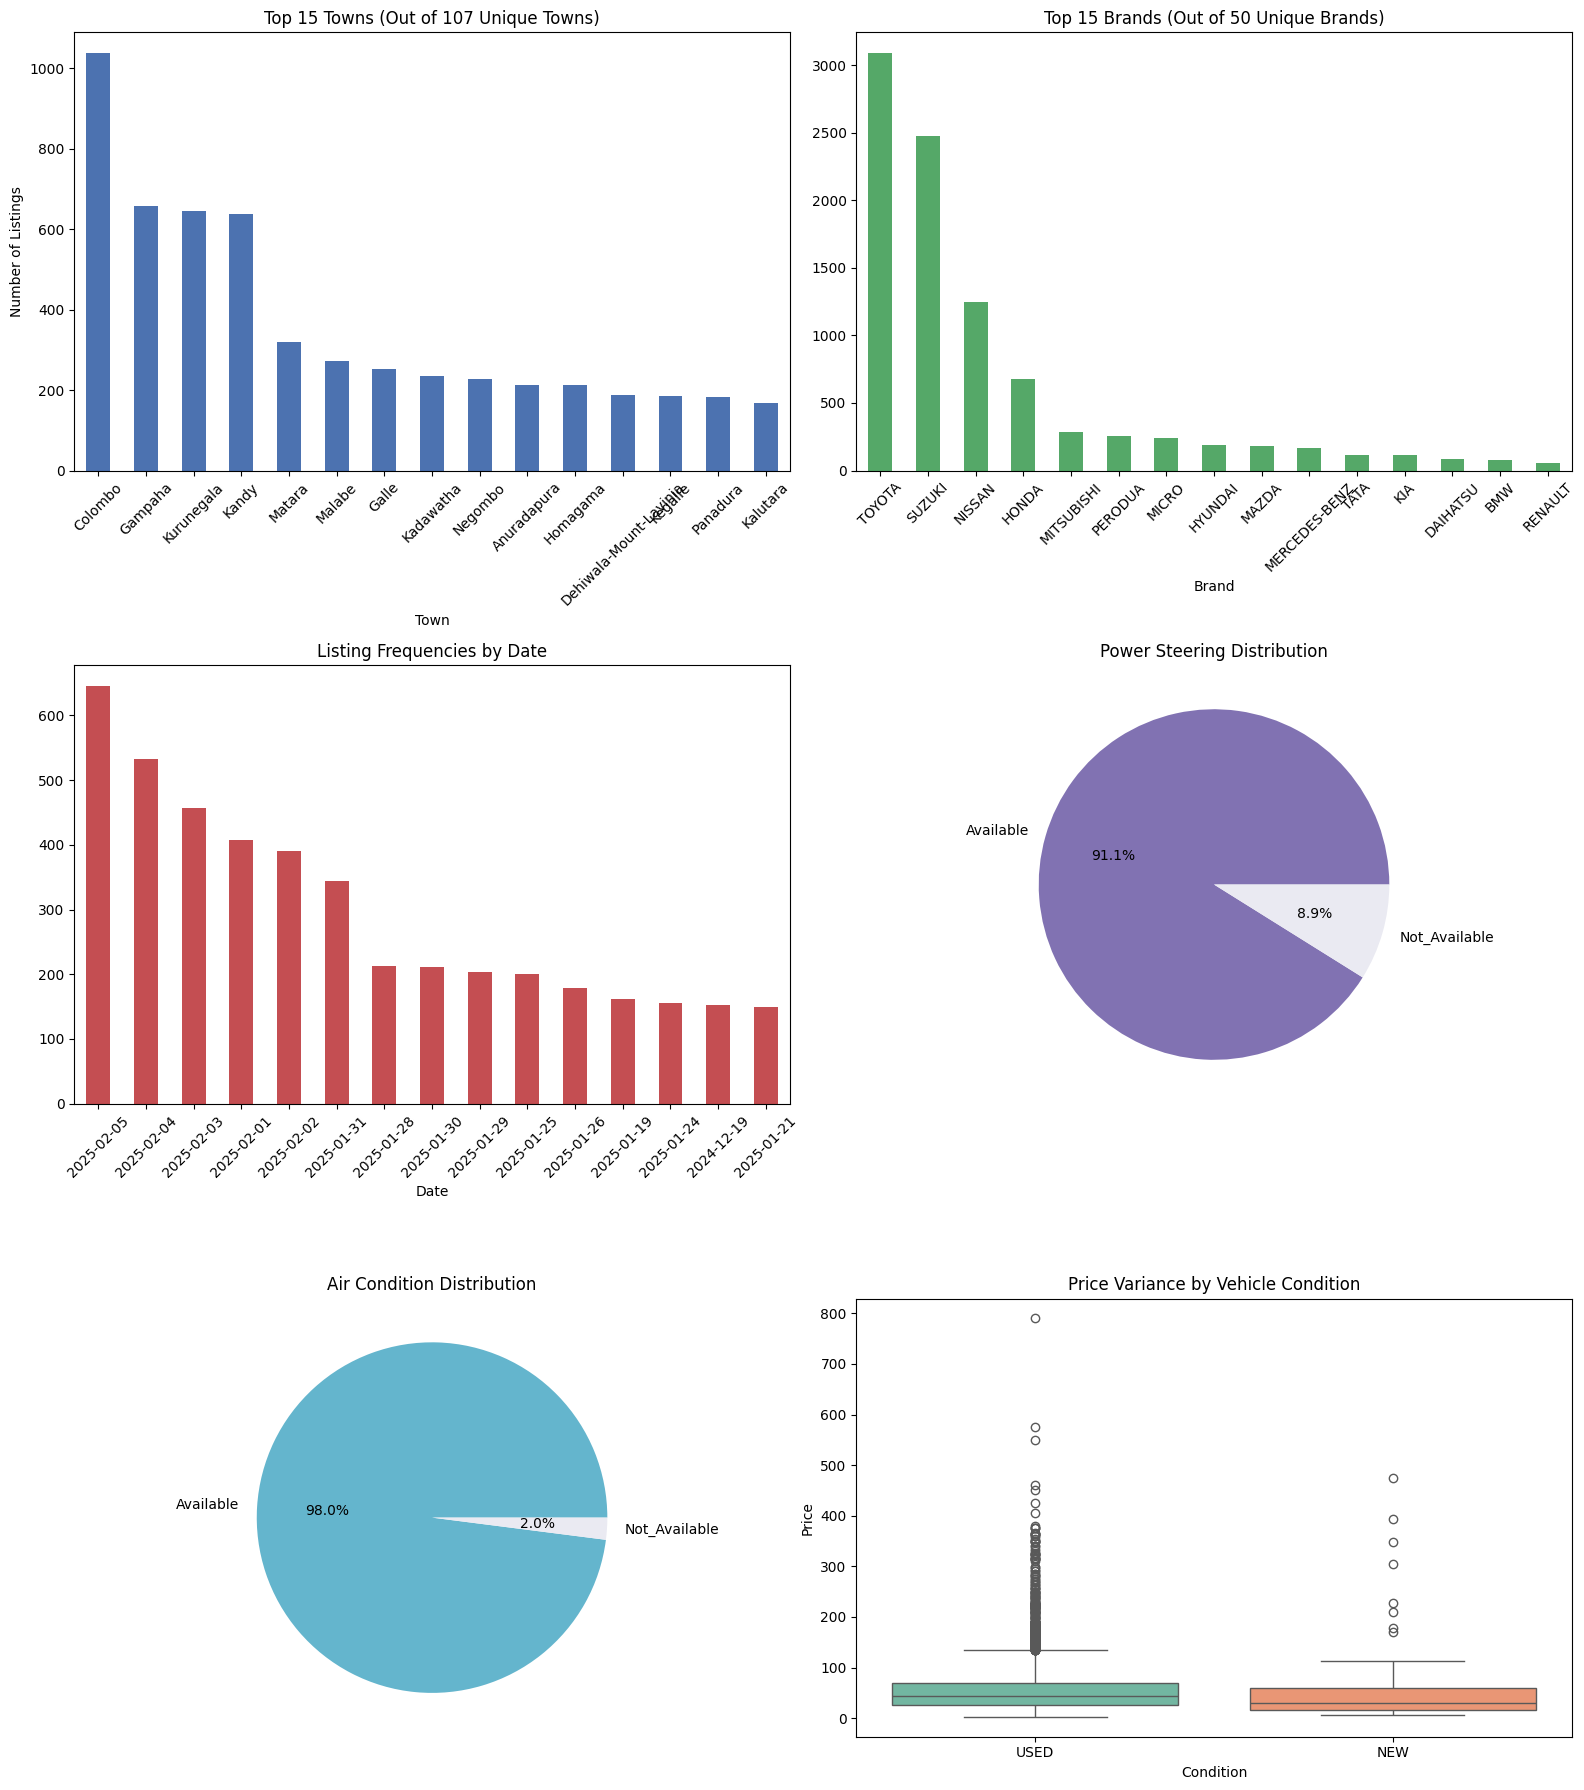

In [92]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

# 1. Town (High Cardinality Proof)
town_counts = raw_df['Town'].value_counts()
town_counts.head(15).plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title(f'Top 15 Towns (Out of {len(town_counts)} Unique Towns)')
axes[0].set_ylabel('Number of Listings')
axes[0].tick_params(axis='x', rotation=45)

# 2. Brand Distribution
brand_counts = raw_df['Brand'].value_counts()
brand_counts.head(15).plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title(f'Top 15 Brands (Out of {len(brand_counts)} Unique Brands)')
axes[1].tick_params(axis='x', rotation=45)

# 3. Date Distribution (Proving it's just scraping/listing metadata)
if 'Date' in raw_df.columns:
    raw_df['Date'].value_counts().head(15).plot(kind='bar', ax=axes[2], color='#C44E52')
    axes[2].set_title('Listing Frequencies by Date')
    axes[2].tick_params(axis='x', rotation=45)

# 4. Power Steering (Zero Variance Proof)
if 'POWER STEERING' in raw_df.columns:
    raw_df['POWER STEERING'].value_counts().plot(kind='pie', ax=axes[3], autopct='%1.1f%%', colors=['#8172B2', '#EAEAF2'])
    axes[3].set_title('Power Steering Distribution')
    axes[3].set_ylabel('')

# 5. Air Condition (Zero Variance Proof)
if 'AIR CONDITION' in raw_df.columns:
    raw_df['AIR CONDITION'].value_counts().plot(kind='pie', ax=axes[4], autopct='%1.1f%%', colors=['#64B5CD', '#EAEAF2'])
    axes[4].set_title('Air Condition Distribution')
    axes[4].set_ylabel('')

# 6. Condition vs Price (Validating a kept feature)
sns.boxplot(data=raw_df, x='Condition', y='Price', ax=axes[5], palette='Set2')
axes[5].set_title('Price Variance by Vehicle Condition')

plt.tight_layout()
plt.show()

## 2. Column roles

The final dataset has ten columns: eight vehicle inputs, the target `Price`, and listing metadata `Date`. Only the eight inputs are sent to the model. Keeping Date in the CSV does not make it a predictor.


In [2]:
# Column roles: Eight columns are predictors; Price is the target in lakhs and Date is listing metadata..
# These are the values supplied to the prediction model.
FEATURES = [
    "Brand",
    "Model",
    "YOM",
    "Engine (cc)",
    "Gear",
    "Fuel Type",
    "Millage(KM)",
    "Condition",
]

# This is what the model learns to predict.
TARGET = "Price"

# Retained for data validation and describing the data period.
# It is not supplied to the prediction model.
METADATA = "Date"

DATASET_COLUMNS = FEATURES + [TARGET, METADATA]

EXCLUDED_COLUMNS = [
    "Town",
    "Leasing",
    "AIR CONDITION",
    "POWER STEERING",
    "POWER MIRROR",
    "POWER WINDOW",
]

print("Model inputs:", FEATURES)
print("Prediction target:", TARGET)
print("Retained metadata:", METADATA)
print("Excluded original columns:", EXCLUDED_COLUMNS)

Model inputs: ['Brand', 'Model', 'YOM', 'Engine (cc)', 'Gear', 'Fuel Type', 'Millage(KM)', 'Condition']
Prediction target: Price
Retained metadata: Date
Excluded original columns: ['Town', 'Leasing', 'AIR CONDITION', 'POWER STEERING', 'POWER MIRROR', 'POWER WINDOW']


## 3. Column selection

The audit compares column completeness and describes the practical reasons for retaining or excluding each original column. Availability and domain reasoning justify a usable input set; they do not establish that excluded columns have no predictive information.


In [95]:
# Column selection: Compare availability and practical relevance.
roles = {
    "Brand": "Predictor",
    "Model": "Predictor",
    "YOM": "Predictor",
    "Engine (cc)": "Predictor",
    "Gear": "Predictor",
    "Fuel Type": "Predictor",
    "Millage(KM)": "Predictor",
    "Condition": "Predictor",
    "Price": "Target",
    "Date": "Metadata",
    "Town": "Excluded",
    "Leasing": "Excluded",
    "AIR CONDITION": "Excluded",
    "POWER STEERING": "Excluded",
    "POWER MIRROR": "Excluded",
    "POWER WINDOW": "Excluded",
}

reasons = {
    "Brand": "Identifies the vehicle manufacturer and market segment.",
    "Model": "Identifies the vehicle product and specifications.",
    "YOM": "Represents vehicle age and depreciation.",
    "Engine (cc)": "Represents engine size, vehicle class and operating cost.",
    "Gear": "Transmission type can affect demand and price.",
    "Fuel Type": "Fuel technology affects demand and operating cost.",
    "Millage(KM)": "Represents vehicle usage and wear.",
    "Condition": "Separates new and used vehicles.",
    "Price": "This is the value the regression model must predict.",
    "Date": "Retained to validate records and describe the listing period; excluded from model inputs.",
    "Town": "We can't define the town while inputting the data into the model, as it is not a predictor of price.",
    "Leasing": "Describes the seller's financial arrangement rather than the vehicle itself.",
    "AIR CONDITION": "Has low variation in the original data.",
    "POWER STEERING": "Has low variation in the original data.",
    "POWER MIRROR": "Has low variation in the original data.",
    "POWER WINDOW": "Has low variation in the original data.",
}

rows = []

for column in legacy_raw.columns:
    legacy_present = column in legacy_raw.columns
    scraped_present = column in scraped_raw.columns
    legacy_completeness = legacy_raw[column].notna().mean() * 100
    scraped_completeness = scraped_raw[column].notna().mean() * 100 if scraped_present else np.nan


    rows.append({
        "Column": column,
        "Role": roles[column],
        "Unique original values": legacy_raw[column].nunique(dropna=True),
        "Reason": reasons[column],
    })

selection_audit = pd.DataFrame(rows)
# Show the completeness evidence and selection reasons.
display(selection_audit)


,Column,Role,Unique original values,Reason
0,Brand,Predictor,50,Identifies the vehicle manufacturer and market...
1,Model,Predictor,1555,Identifies the vehicle product and specificati...
2,YOM,Predictor,62,Represents vehicle age and depreciation.
3,Engine (cc),Predictor,278,"Represents engine size, vehicle class and oper..."
4,Gear,Predictor,2,Transmission type can affect demand and price.
5,Fuel Type,Predictor,4,Fuel technology affects demand and operating c...
6,Millage(KM),Predictor,62,Represents vehicle usage and wear.
7,Town,Excluded,107,We can't define the town while inputting the d...
8,Date,Metadata,65,Retained to validate records and describe the ...
9,Leasing,Excluded,2,Describes the seller's financial arrangement r...


## 4. Cleaning rules

Cleaning standardizes text, transmission and condition labels, converts numeric values and dates, rejects invalid records, and removes duplicates. The functions below define those rules; the following cell applies them. Supplied mileage is retained.


In [4]:
# Cleaning rules: Normalize categories and validate numeric ranges.
TEXT_COLUMNS = [
    "Brand",
    "Model",
    "Gear",
    "Fuel Type",
    "Condition",
]

NUMERIC_COLUMNS = [
    "YOM",
    "Engine (cc)",
    "Millage(KM)",
    "Price",
]


def clean_text(series):
    """Standardize categorical text."""
    result = (
        series.astype("string")
        .str.strip()
        .str.upper()
        .str.replace(r"\s+", " ", regex=True)
    )

    result = result.replace({
        "": pd.NA,
        "NAN": pd.NA,
        "NONE": pd.NA,
    })

    return result


def clean_number(series):
    """Convert an already standardized numeric column safely."""
    return pd.to_numeric(series, errors="coerce")


def clean_source(frame, source_name):
    """Clean one of the two prepared data sources."""
    cleaned = frame.copy()

    cleaned = cleaned.drop(
        columns=[
            column for column in cleaned.columns
            if column.lower().startswith("unnamed")
        ],
        errors="ignore"
    )

    missing_columns = [
        column for column in DATASET_COLUMNS
        if column not in cleaned.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{source_name} is missing required columns: {missing_columns}"
        )

    # Keep only the final unified columns.
    cleaned = cleaned[DATASET_COLUMNS].copy()

    for column in TEXT_COLUMNS:
        cleaned[column] = clean_text(cleaned[column])

    for column in NUMERIC_COLUMNS:
        cleaned[column] = clean_number(cleaned[column])

    # Standardize transmission.
    cleaned["Gear"] = cleaned["Gear"].replace({
        "TIPTRONIC": "AUTOMATIC",
        "AUTO": "AUTOMATIC",
    })

    # Standardize vehicle condition.
    cleaned["Condition"] = cleaned["Condition"].replace({
        "RECONDITIONED": "USED",
        "RE-CONDITIONED": "USED",
    })

    # Imported vehicles with mileage are treated as used.
    import_mask = cleaned["Condition"].eq("IMPORT")
    cleaned.loc[
        import_mask & cleaned["Millage(KM)"].gt(0),
        "Condition"
    ] = "USED"

    cleaned.loc[
        import_mask & cleaned["Millage(KM)"].eq(0),
        "Condition"
    ] = "NEW"

    # Standardize dates.
    parsed_dates = pd.to_datetime(
        cleaned["Date"],
        errors="coerce",
        format="mixed"
    )

    cleaned["Date"] = parsed_dates.dt.strftime("%Y-%m-%d")

    numeric_is_valid = np.isfinite(
        cleaned[NUMERIC_COLUMNS]
    ).all(axis=1)

    category_is_valid = cleaned[TEXT_COLUMNS].notna().all(axis=1)

    valid = (
        numeric_is_valid
        & category_is_valid
        & cleaned["Date"].notna()
        & cleaned["Price"].gt(0)
        & cleaned["YOM"].between(1886, REFERENCE_YEAR)
        & cleaned["YOM"].mod(1).eq(0)
        & cleaned["Engine (cc)"].between(0, 20_000)
        & cleaned["Millage(KM)"].between(0, 3_000_000)
        & cleaned["Gear"].isin(["AUTOMATIC", "MANUAL"])
        & cleaned["Condition"].isin(["USED", "NEW"])
    )

    # Electric vehicles may use zero for engine capacity.
    electric = cleaned["Fuel Type"].eq("ELECTRIC")

    valid_engine = (
        (electric & cleaned["Engine (cc)"].eq(0))
        | (~electric & cleaned["Engine (cc)"].gt(0))
    )

    valid &= valid_engine

    rejected_count = int((~valid).sum())

    cleaned = (
        cleaned.loc[valid, DATASET_COLUMNS]
        .drop_duplicates(DATASET_COLUMNS)
        .reset_index(drop=True)
    )

    cleaned["YOM"] = cleaned["YOM"].astype(int)

    print(
        f"{source_name}: "
        f"{len(frame):,} input rows, "
        f"{len(cleaned):,} accepted rows, "
        f"{rejected_count:,} invalid rows rejected."
    )

    return cleaned

## 5. Merge and save

Apply the same cleaning rules to both prepared sources, combine them into one dataset, remove repeated rows, and save `data/cars.csv`. The saved row order is also used by the model evaluation split indices.


In [5]:
# Merge and save: Combine the accepted records, remove duplicates and save data/cars.csv..
legacy_clean = clean_source(
    legacy_raw,
    "Original Kaggle dataset"
)

scraped_clean = clean_source(
    scraped_raw,
    "Scraped dataset"
)

before_cross_source_deduplication = (
    len(legacy_clean) + len(scraped_clean)
)

data = pd.concat(
    [legacy_clean, scraped_clean],
    ignore_index=True
)

data = (
    data.drop_duplicates(DATASET_COLUMNS)
    .sort_values(["Brand", "Model", "YOM"])
    .reset_index(drop=True)
)

cross_source_duplicates = (
    before_cross_source_deduplication - len(data)
)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
data.to_csv(OUTPUT_PATH, index=False)

print("\nFinal dataset shape:", data.shape)
print("Cross-source duplicates removed:", cross_source_duplicates)
print("Saved to:", OUTPUT_PATH)

display(data.head())

Original Kaggle dataset: 9,788 input rows, 9,624 accepted rows, 69 invalid rows rejected.
Scraped dataset: 2,252 input rows, 2,126 accepted rows, 0 invalid rows rejected.

Final dataset shape: (11750, 10)
Cross-source duplicates removed: 0
Saved to: /Users/kathuskanthavarajah/Desktop/used_car_valuation_project/data/cars.csv


,Brand,Model,YOM,Engine (cc),Gear,Fuel Type,Millage(KM),Condition,Price,Date
0,AUDI,A1,2016,990.0,AUTOMATIC,PETROL,99000.0,USED,100.0,2025-02-05
1,AUDI,A1,2016,1000.0,AUTOMATIC,PETROL,139000.0,USED,76.0,2026-09-26
2,AUDI,A1,2016,1000.0,AUTOMATIC,PETROL,105000.0,USED,80.0,2026-09-26
3,AUDI,A1,2017,1000.0,AUTOMATIC,PETROL,88000.0,USED,97.0,2025-01-14
4,AUDI,A1,2017,1000.0,AUTOMATIC,PETROL,88000.0,USED,107.0,2024-12-21


## 6. Saved-data checks

Reload the saved CSV and verify its columns, missing values, duplicates, positive prices and basic ranges. An assertion failure stops execution so that an invalid dataset does not silently continue to training.


In [6]:
# Saved-data checks: Check missing values, duplicates, ranges and the saved column order..
saved_data = pd.read_csv(OUTPUT_PATH)

validation = pd.Series({
    "Rows": len(saved_data),
    "Columns": len(saved_data.columns),
    "Missing values": int(saved_data.isna().sum().sum()),
    "Duplicate rows": int(saved_data.duplicated().sum()),
    "Minimum year": saved_data["YOM"].min(),
    "Maximum year": saved_data["YOM"].max(),
    "Minimum price (lakhs)": saved_data["Price"].min(),
    "Maximum price (lakhs)": saved_data["Price"].max(),
    "Earliest listing date": saved_data["Date"].min(),
    "Latest listing date": saved_data["Date"].max(),
})

display(validation)

assert list(saved_data.columns) == DATASET_COLUMNS
assert saved_data.isna().sum().sum() == 0
assert saved_data.duplicated().sum() == 0
assert saved_data["Price"].gt(0).all()

print("Saved dataset validation passed.")

Rows                          11750
Columns                          10
Missing values                    0
Duplicate rows                    0
Minimum year                   1950
Maximum year                   2026
Minimum price (lakhs)          2.65
Maximum price (lakhs)        2550.0
Earliest listing date    2024-12-03
Latest listing date      2026-09-27
dtype: object

Saved dataset validation passed.


## 7. Descriptive statistics

Numeric summaries show typical values, spread and extremes. Categorical summaries show common labels and how many different labels exist. These summaries help identify imbalanced categories and unusual observations.


In [7]:
# Descriptive statistics: Inspect numeric ranges and category frequencies before modelling..
print("Dataset information:")
data.info()

print("\nNumeric summary:")
display(
    data[
        ["YOM", "Engine (cc)", "Millage(KM)", "Price"]
    ].describe().T
)

print("\nCategorical summary:")
display(
    data[
        ["Brand", "Model", "Gear", "Fuel Type", "Condition"]
    ].describe().T
)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11750 entries, 0 to 11749
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Brand        11750 non-null  string 
 1   Model        11750 non-null  string 
 2   YOM          11750 non-null  int64  
 3   Engine (cc)  11750 non-null  float64
 4   Gear         11750 non-null  string 
 5   Fuel Type    11750 non-null  string 
 6   Millage(KM)  11750 non-null  float64
 7   Condition    11750 non-null  string 
 8   Price        11750 non-null  float64
 9   Date         11750 non-null  object 
dtypes: float64(3), int64(1), object(1), string(5)
memory usage: 918.1+ KB

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
YOM,11750.0,2008.966723,10.788467,1950.00,2002.00,2011.0,2016.000000,2026.0
Engine (cc),11750.0,1278.142536,475.426465,200.00,1000.00,1300.0,1500.000000,5700.0
Millage(KM),11750.0,175555.978043,116881.044689,0.00,99000.00,154000.0,242000.000000,759000.0
Price,11750.0,71.661073,95.564952,2.65,28.75,54.0,81.540385,2550.0



Categorical summary:


,count,unique,top,freq
Brand,11750,56,TOYOTA,3743
Model,11750,1698,ALTO,424
Gear,11750,2,AUTOMATIC,8141
Fuel Type,11750,3,PETROL,9185
Condition,11750,2,USED,11052


## 8. Data quality

The table lists data types, missing counts, missing percentages and distinct-value counts. Check it before modelling to confirm the cleaned dataset is usable.


In [8]:
# Data quality: Summarize missing values and distinct values..
quality_summary = pd.DataFrame({
    "Data type": data.dtypes.astype(str),
    "Missing values": data.isna().sum(),
    "Missing percentage": data.isna().mean() * 100,
    "Unique values": data.nunique(),
})

display(
    quality_summary.round(2)
)

,Data type,Missing values,Missing percentage,Unique values
Brand,string,0,0.0,56
Model,string,0,0.0,1698
YOM,int64,0,0.0,66
Engine (cc),float64,0,0.0,314
Gear,string,0,0.0,2
Fuel Type,string,0,0.0,3
Millage(KM),float64,0,0.0,709
Condition,string,0,0.0,2
Price,float64,0,0.0,2063
Date,object,0,0.0,88


## 9. Exploratory charts

The plots show price distribution and relationships with manufacture year, engine capacity, mileage, fuel type and condition. These are descriptive associations; differences between categories may also reflect differences in brand, age and vehicle class.


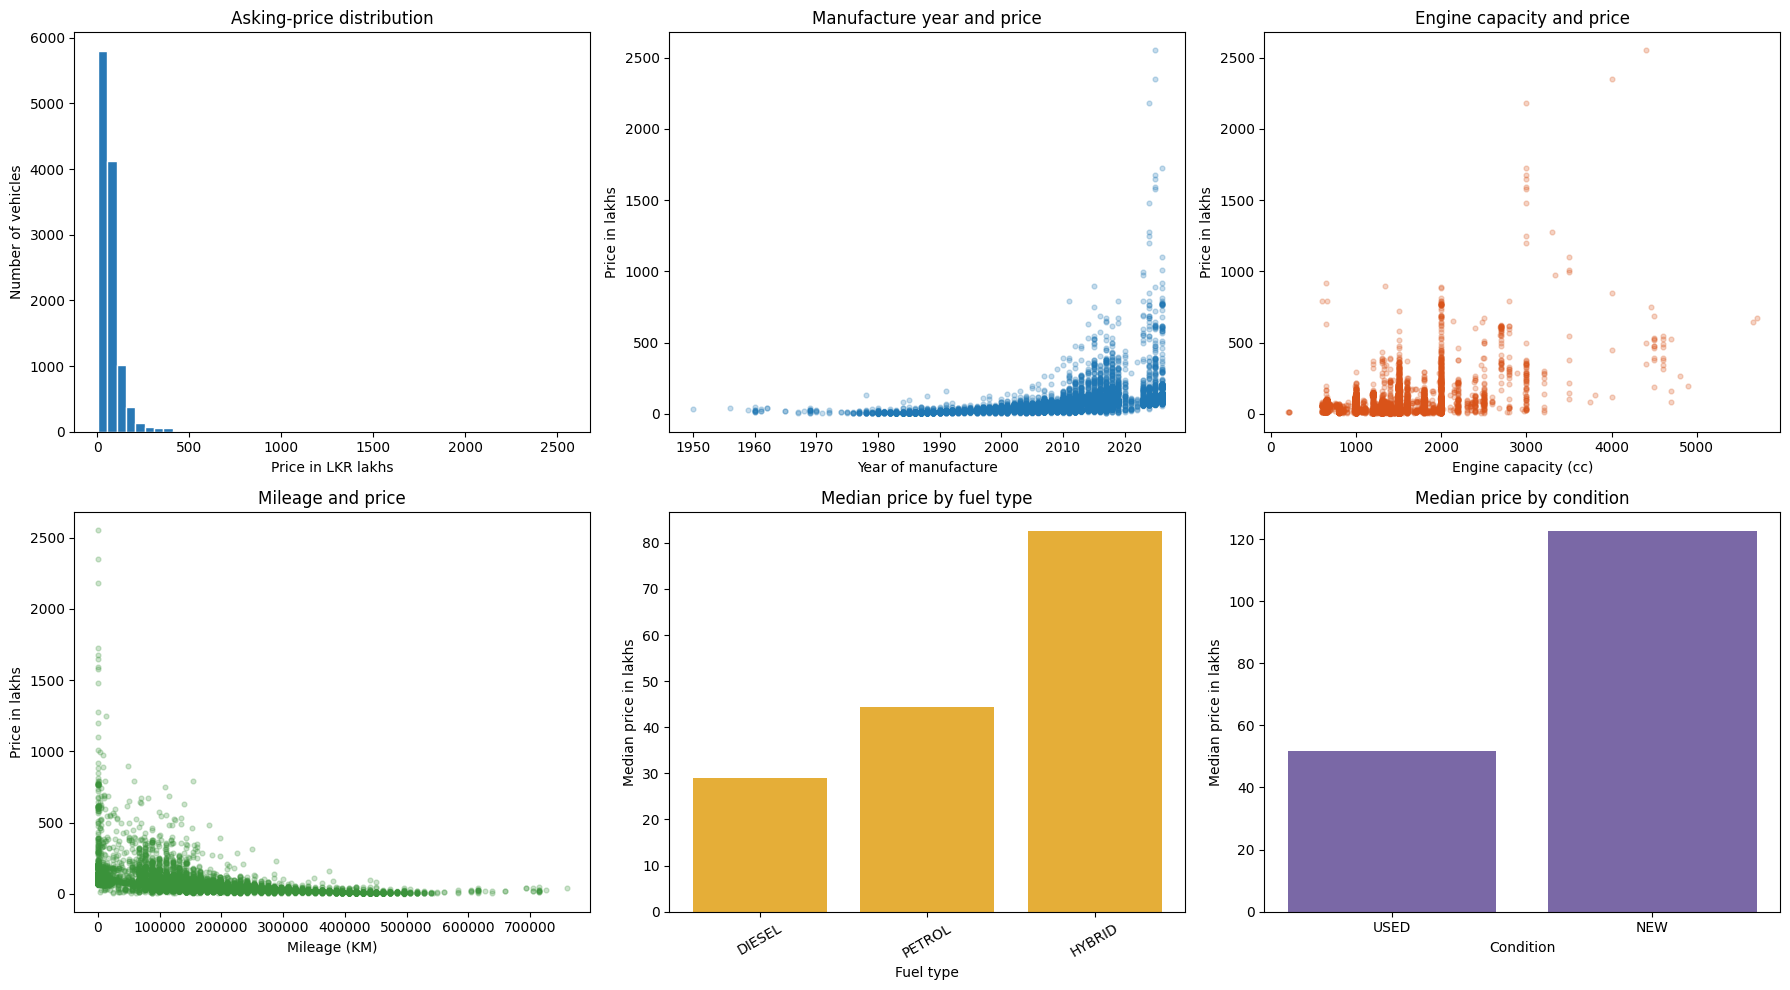

In [9]:
# Exploratory charts: Explore price relationships; association does not establish causation..
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price distribution
axes[0, 0].hist(
    data["Price"],
    bins=50,
    color="#2878B5",
    edgecolor="white"
)
axes[0, 0].set_title("Asking-price distribution")
axes[0, 0].set_xlabel("Price in LKR lakhs")
axes[0, 0].set_ylabel("Number of vehicles")

# Year and price
axes[0, 1].scatter(
    data["YOM"],
    data["Price"],
    alpha=0.25,
    s=12
)
axes[0, 1].set_title("Manufacture year and price")
axes[0, 1].set_xlabel("Year of manufacture")
axes[0, 1].set_ylabel("Price in lakhs")

# Engine and price
axes[0, 2].scatter(
    data["Engine (cc)"],
    data["Price"],
    alpha=0.25,
    s=12,
    color="#D95319"
)
axes[0, 2].set_title("Engine capacity and price")
axes[0, 2].set_xlabel("Engine capacity (cc)")
axes[0, 2].set_ylabel("Price in lakhs")

# Mileage and price
axes[1, 0].scatter(
    data["Millage(KM)"],
    data["Price"],
    alpha=0.25,
    s=12,
    color="#3A923A"
)
axes[1, 0].set_title("Mileage and price")
axes[1, 0].set_xlabel("Mileage (KM)")
axes[1, 0].set_ylabel("Price in lakhs")

# Fuel type and median price
fuel_price = (
    data.groupby("Fuel Type")["Price"]
    .median()
    .sort_values()
)

axes[1, 1].bar(
    fuel_price.index,
    fuel_price.values,
    color="#E5AE38"
)
axes[1, 1].set_title("Median price by fuel type")
axes[1, 1].set_xlabel("Fuel type")
axes[1, 1].set_ylabel("Median price in lakhs")
axes[1, 1].tick_params(axis="x", rotation=30)

# Condition and median price
condition_price = (
    data.groupby("Condition")["Price"]
    .median()
    .sort_values()
)

axes[1, 2].bar(
    condition_price.index,
    condition_price.values,
    color="#7A68A6"
)
axes[1, 2].set_title("Median price by condition")
axes[1, 2].set_xlabel("Condition")
axes[1, 2].set_ylabel("Median price in lakhs")

plt.tight_layout()
plt.show()

## 10. Numeric associations

Spearman correlation measures monotonic relationships between numeric variables on a scale from −1 to 1. A low individual correlation does not prove that a feature is unhelpful in a model with interactions.


,YOM,Engine (cc),Millage(KM),Price
YOM,1.000000,-0.381763,-0.977257,0.724345
Engine (cc),-0.381763,1.000000,0.374839,0.121488
Millage(KM),-0.977257,0.374839,1.000000,-0.708747
Price,0.724345,0.121488,-0.708747,1.000000


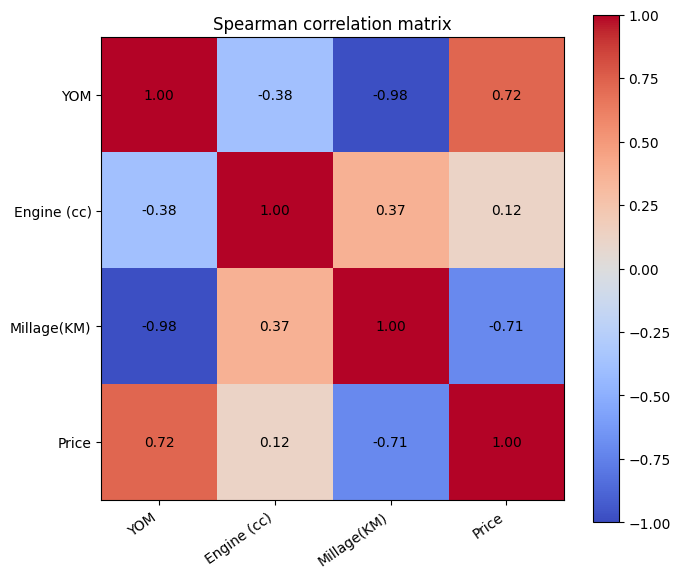

In [10]:
# Numeric associations: Spearman correlation describes monotonic relationships, not independent feature contributions..
numeric_analysis = data[
    ["YOM", "Engine (cc)", "Millage(KM)", "Price"]
]

spearman_correlation = numeric_analysis.corr(method="spearman")

display(spearman_correlation)

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    spearman_correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(spearman_correlation.columns)))
ax.set_xticklabels(
    spearman_correlation.columns,
    rotation=35,
    ha="right"
)

ax.set_yticks(range(len(spearman_correlation.index)))
ax.set_yticklabels(spearman_correlation.index)

for row in range(len(spearman_correlation.index)):
    for column in range(len(spearman_correlation.columns)):
        ax.text(
            column,
            row,
            f"{spearman_correlation.iloc[row, column]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Spearman correlation matrix")
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

## 11. Feature engineering

The pipeline creates age (`2026 − YOM`), combined brand-model identity, and `log(1 + mileage)`. Age is a transformation of year rather than independent new information. Median imputation, scaling and categorical encoding are learned inside the training folds to avoid using validation data during fitting.


In [11]:
# Feature engineering: Create age, brand-model and log mileage.
from backend.features import VehicleFeatures

feature_engineer = VehicleFeatures(
    use_mileage=True,
    use_engine=True,
    reference_year=REFERENCE_YEAR
)

engineered_features = feature_engineer.fit_transform(
    data[FEATURES]
)

print("Original model inputs:")
print(FEATURES)

print("\nColumns after feature engineering:")
print(engineered_features.columns.tolist())

display(
    pd.concat(
        [
            data[
                ["Brand", "Model", "YOM", "Millage(KM)"]
            ].head(),
            engineered_features[
                [
                    "Age at reference year",
                    "Brand model",
                    "Log mileage",
                ]
            ].head(),
        ],
        axis=1,
    )
)

Original model inputs:
['Brand', 'Model', 'YOM', 'Engine (cc)', 'Gear', 'Fuel Type', 'Millage(KM)', 'Condition']

Columns after feature engineering:
['YOM', 'Brand', 'Model', 'Gear', 'Fuel Type', 'Condition', 'Engine (cc)', 'Millage(KM)', 'Age at reference year', 'Brand model', 'Log mileage']


,Brand,Model,YOM,Millage(KM),Age at reference year,Brand model,Log mileage
0,AUDI,A1,2016,99000.0,10.0,AUDI | A1,11.502885
1,AUDI,A1,2016,139000.0,10.0,AUDI | A1,11.842236
2,AUDI,A1,2016,105000.0,10.0,AUDI | A1,11.561725
3,AUDI,A1,2017,88000.0,9.0,AUDI | A1,11.385103
4,AUDI,A1,2017,88000.0,9.0,AUDI | A1,11.385103


## 12. Engineered-feature charts

These charts illustrate the engineered features and their price relationships. Brand-model groups need at least ten listings for the displayed summary. Charts alone do not demonstrate that a transformation improves validation performance.


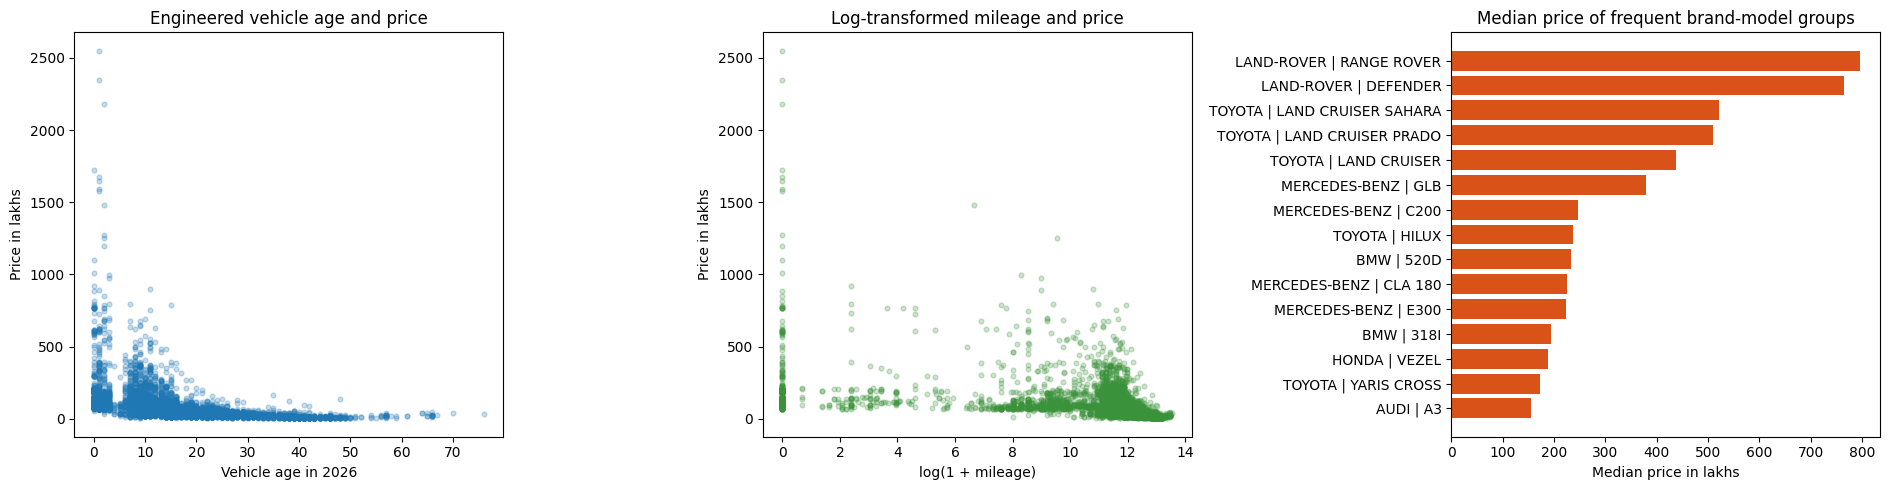

In [12]:
# Engineered-feature charts: Visualize transformed values and price patterns.
engineering_visual = pd.DataFrame({
    "Price": data["Price"],
    "Age": engineered_features["Age at reference year"],
    "Log mileage": engineered_features["Log mileage"],
    "Brand model": engineered_features["Brand model"],
})

brand_model_summary = (
    engineering_visual
    .groupby("Brand model")
    .agg(
        Median_price=("Price", "median"),
        Listings=("Price", "size")
    )
)

brand_model_summary = (
    brand_model_summary[
        brand_model_summary["Listings"] >= 10
    ]
    .sort_values("Median_price", ascending=False)
    .head(15)
    .sort_values("Median_price")
)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].scatter(
    engineering_visual["Age"],
    engineering_visual["Price"],
    alpha=0.25,
    s=12
)
axes[0].set_title("Engineered vehicle age and price")
axes[0].set_xlabel("Vehicle age in 2026")
axes[0].set_ylabel("Price in lakhs")

axes[1].scatter(
    engineering_visual["Log mileage"],
    engineering_visual["Price"],
    alpha=0.25,
    s=12,
    color="#3A923A"
)
axes[1].set_title("Log-transformed mileage and price")
axes[1].set_xlabel("log(1 + mileage)")
axes[1].set_ylabel("Price in lakhs")

axes[2].barh(
    brand_model_summary.index,
    brand_model_summary["Median_price"],
    color="#D95319"
)
axes[2].set_title("Median price of frequent brand-model groups")
axes[2].set_xlabel("Median price in lakhs")

plt.tight_layout()
plt.show()

## 13. Train six models

Train exactly six candidates: **Median baseline, Linear regression, Ridge regression, Decision tree, Random forest, and Gradient boosting**. Similar vehicle profiles remain together during splitting. Three-fold grouped validation compares the candidates, and the lowest mean validation MAE chooses the winner. If Random forest wins, its settings are tuned on development folds. Holdout results do not determine the choice. Save only the selected new bundle as `models/selected_six_model.joblib`. The code reloads the training module to prevent an open kernel using an older definition.


In [13]:
# Train six models: Train Median baseline, Linear regression, Ridge regression, Decision tree, Random forest and Gradient boosting.
# Reload after editing train.py so an open kernel cannot use old candidates.
import importlib
import train
train = importlib.reload(train)
expected_models = {
    "Median baseline", "Linear regression", "Ridge regression",
    "Decision tree", "Random forest", "Gradient boosting",
}
assert set(train.candidates()) == expected_models
MODEL_PATH = train.MODEL

# This function:
# 1. creates a grouped development/holdout split;
# 2. trains all six candidate models;
# 3. compares them using three-fold grouped cross-validation;
# 4. selects the model with the lowest mean validation MAE;
# 5. evaluates the selected model on the holdout data;
# 6. saves the selected model to models/selected_six_model.joblib.

bundle = train.train_model(data)

print("\nSaved selected model to:")
print(MODEL_PATH)

Comparing: Median baseline


Comparing: Linear regression


Comparing: Ridge regression


Comparing: Decision tree


Comparing: Random forest


...

Tuning Random forest: leaf=2, features=0.7


Tuning Random forest: leaf=3, features=1.0


            Model    CV MAE   CV RMSE     CV R2  CV MAPE_pct  CV Within_10_pct  CV Within_20_pct  Holdout MAE  Holdout RMSE  Holdout R2  Holdout MAPE_pct  Holdout Within_10_pct  Holdout Within_20_pct
    Random forest 10.498245 37.252134  0.847944    17.198541         59.185048         79.200071     9.227587     46.262164    0.763264         14.408901              65.986949              83.768352
    Decision tree 13.681982 47.479807  0.749979    20.499368         52.151093         72.316762    12.337476     58.860693    0.616767         17.162044              56.688418              77.773246
Gradient boosting 13.950333 48.684383  0.739987    23.766156         42.181279         67.165110    12.432202     55.371955    0.660850         21.885132              47.716150              71.125612
Linear regression 19.935247 49.414399  0.733145    48.041138         33.426908         52.431180    20.468984     66.505966    0.510747         44.598342              37.601958              57.667210


Selected: Random forest 
Holdout: {
  "MAE": 9.006191741885592,
  "RMSE": 48.207637190455365,
  "R2": 0.7429341991257756,
  "MAPE_pct": 13.597322158512885,
  "Within_10_pct": 68.14845024469821,
  "Within_20_pct": 84.13539967373572
}



Saved selected model to:
/Users/kathuskanthavarajah/Desktop/used_car_valuation_project/models/selected_six_model.joblib


## 14. All evaluation measures
MAE and RMSE are in lakhs; lower is better. MAPE_pct is mean percentage error; lower is better. R2 and Within_10_pct / Within_20_pct are better when higher. CV values are fold averages. Candidate holdout scores refer to the original configurations; the selected-model table includes any winning tuning.


| Measure | Meaning | Preferred direction |
| --- | --- | --- |
| MAE | Average absolute price error, in lakhs | Lower |
| RMSE | Price error in lakhs, with greater weight on large errors | Lower |
| R2 | Explained variation relative to predicting the mean; can be negative | Higher |
| MAPE_pct | Average absolute percentage price error | Lower |
| Within_10_pct | Percentage of predictions within 10% of actual price | Higher |
| Within_20_pct | Percentage of predictions within 20% of actual price | Higher |

All six candidates are evaluated on the same grouped splits. Validation MAE chooses the winner before holdout results are inspected. The tuned winner's final scores are displayed separately from the original candidate scores.



Cross-validation: mean of three grouped folds


,Model,CV MAE,CV RMSE,CV R2,CV MAPE_pct,CV Within_10_pct,CV Within_20_pct
4,Random forest,10.4982,37.2521,0.8479,17.1985,59.1850,79.2001
3,Decision tree,13.6820,47.4798,0.7500,20.4994,52.1511,72.3168
5,Gradient boosting,13.9503,48.6844,0.7400,23.7662,42.1813,67.1651
1,Linear regression,19.9352,49.4144,0.7331,48.0411,33.4269,52.4312
2,Ridge regression,21.4449,50.9602,0.7161,52.6980,29.4044,48.8711
0,Median baseline,42.7405,97.0743,-0.0331,95.0642,10.4647,19.1223


Candidate holdout evaluation (not used for selection)


,Model,Holdout MAE,Holdout RMSE,Holdout R2,Holdout MAPE_pct,Holdout Within_10_pct,Holdout Within_20_pct
4,Random forest,9.2276,46.2622,0.7633,14.4089,65.9869,83.7684
3,Decision tree,12.3375,58.8607,0.6168,17.1620,56.6884,77.7732
5,Gradient boosting,12.4322,55.3720,0.6608,21.8851,47.7162,71.1256
1,Linear regression,20.4690,66.5060,0.5107,44.5983,37.6020,57.6672
2,Ridge regression,21.0300,64.4926,0.5399,47.3992,35.6852,53.9967
0,Median baseline,43.9307,97.0584,-0.0420,93.1483,7.5449,16.1501


Validation-only tuning of the winning model family


,min_samples_leaf,max_features,CV MAE,CV RMSE,CV R2,CV MAPE_pct,CV Within_10_pct,CV Within_20_pct
0,1,0.7,9.9221,35.8754,0.8589,16.4092,62.0889,80.6518
1,2,0.7,10.5077,36.9898,0.8502,17.2105,59.1097,79.0172
2,3,1.0,11.2143,39.7860,0.8263,17.9549,57.3782,77.5868


Selected model: Random forest
Selected CV MAE: 9.92214219585722


,Selected model holdout
MAE,9.0062
RMSE,48.2076
R2,0.7429
MAPE_pct,13.5973
Within_10_pct,68.1485
Within_20_pct,84.1354


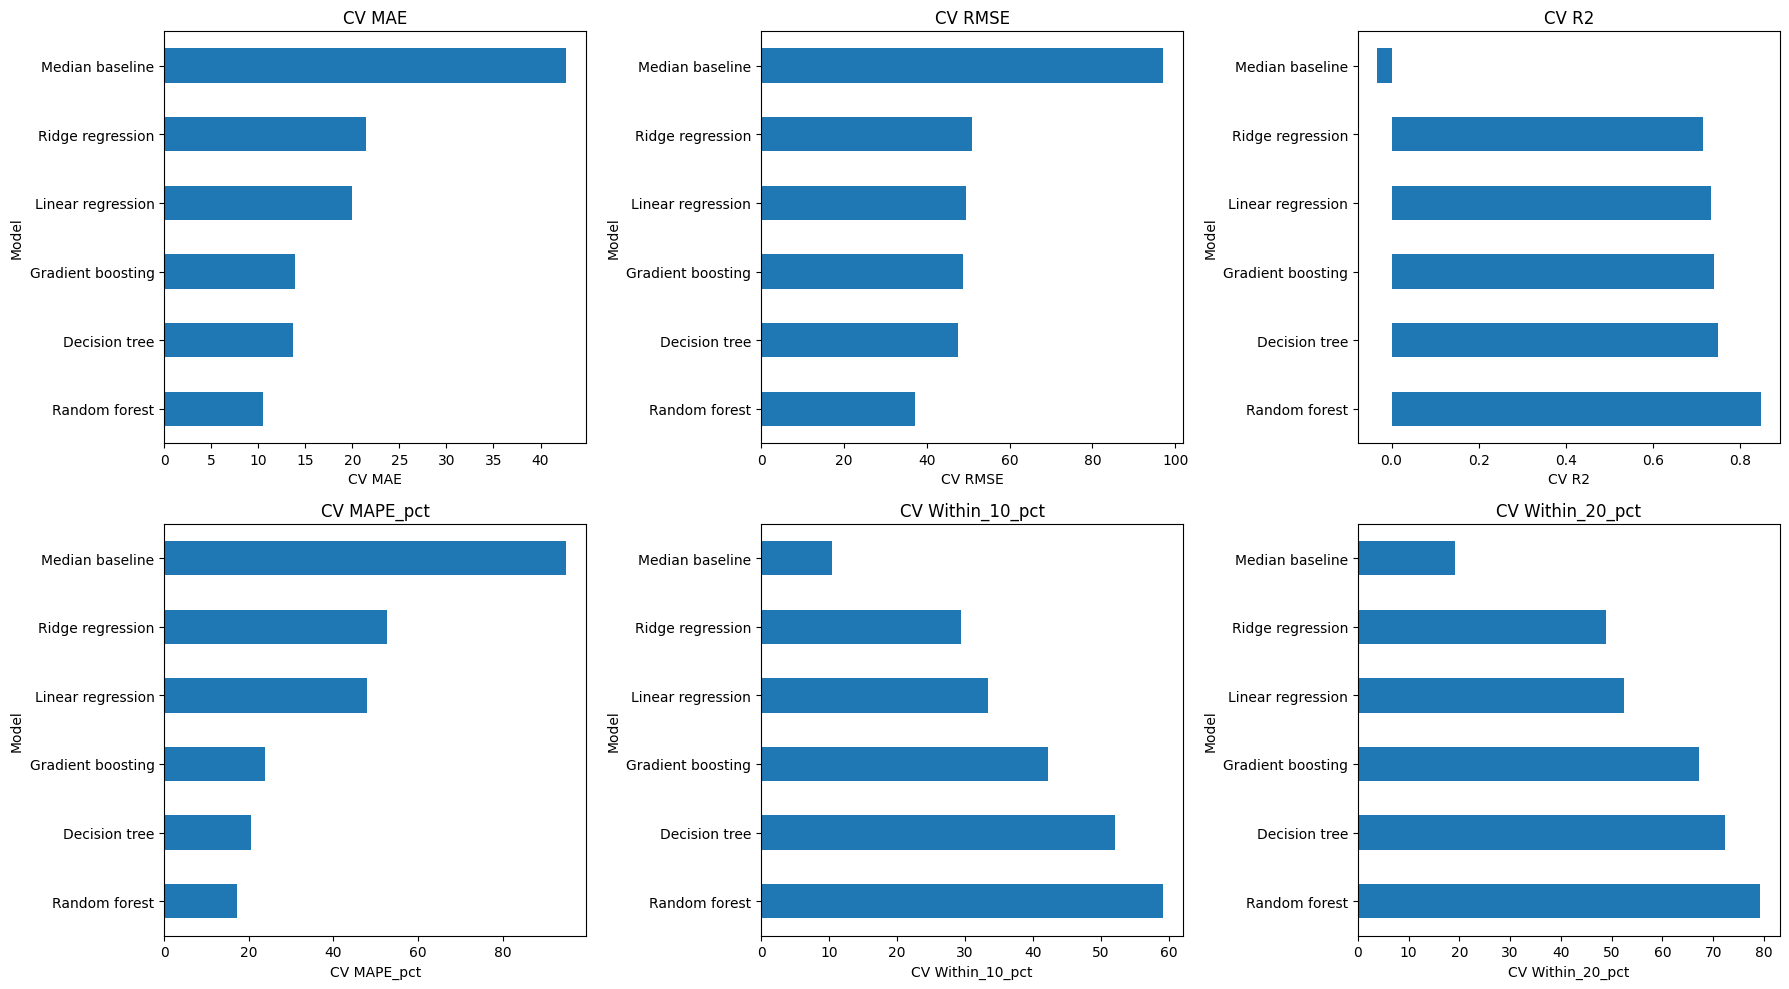

In [14]:
# All evaluation measures: MAE and RMSE are in lakhs; lower is better.
# Display every measure for all six candidates, ordered by selection MAE.
info = bundle["metadata"]["metrics"]
comparison = pd.DataFrame(info["model_comparison"]).sort_values("CV MAE")
# Require all six measures for every requested candidate.
measure_names = ["MAE", "RMSE", "R2", "MAPE_pct", "Within_10_pct", "Within_20_pct"]
cv_columns = ["CV " + name for name in measure_names]
holdout_columns = ["Holdout " + name for name in measure_names]
assert set(comparison["Model"]) == expected_models
assert len(comparison) == 6
assert comparison[cv_columns + holdout_columns].notna().all().all()
pd.set_option("display.max_columns", None)
print("Cross-validation: mean of three grouped folds")
display(comparison[["Model"] + cv_columns].round(4))
print("Candidate holdout evaluation (not used for selection)")
display(comparison[["Model"] + holdout_columns].round(4))
if info["tuning"]:
    print("Validation-only tuning of the winning model family")
    display(pd.DataFrame(info["tuning"]).round(4))
print("Selected model:", info["winner"])
print("Selected CV MAE:", info["selected_cv_mae"])
display(pd.Series(info["test"], name="Selected model holdout").to_frame().round(4))
# Each panel uses its own units; never combine unlike metrics on one axis.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, metric in zip(axes.flat, cv_columns):
    comparison.plot.barh(x="Model", y=metric, ax=ax, legend=False)
    ax.set_title(metric)
    ax.set_xlabel(metric)
plt.tight_layout()
plt.show()


## 15. Prediction

Use the saved bundle’s supported example vehicle and pass the new bundle explicitly to the prediction function. The output shows the estimate in lakhs and rupees. This demonstrates the newly selected model.


In [15]:
# Prediction: Predict using the newly selected bundle explicitly.
from backend.predict import predict_car

example_input = bundle["metadata"]["example"]

print("Example input:")
display(pd.Series(example_input))

prediction = predict_car(
    example_input,
    bundle=bundle
)

print("\nPrediction result:")
display(pd.Series(prediction))

Example input:


brand            NISSAN
model_name         ROOX
yom                2023
engine_cc         660.0
gear          AUTOMATIC
fuel_type        PETROL
millage         10548.0
condition          USED
dtype: object


Prediction result:


predicted_price_lakhs                           83.9167
predicted_price_lkr                           8391665.0
currency                                            LKR
model                                     Random forest
data_period                    [2024-12-03, 2026-09-27]
valuation_basis          Vehicle asking-price estimate.
warnings                                             []
dtype: object